In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
import nltk
import re
import pickle
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [32]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')

ps = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\itsab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\itsab\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [34]:
df = pd.read_csv('../dataset/spam.csv', encoding='latin-1')

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)




Text(0.5, 1.0, 'Target Distribution')

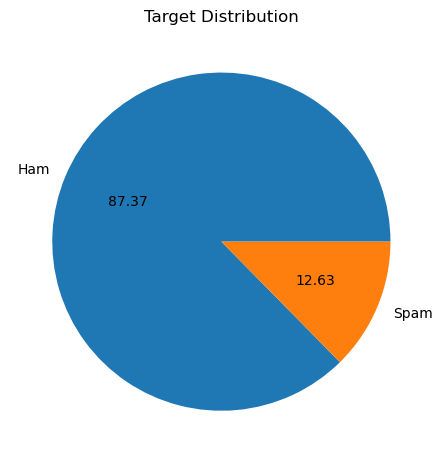

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.pie(df['target'].value_counts(), labels=['Ham','Spam'], autopct="%0.2f")
plt.title('Target Distribution')


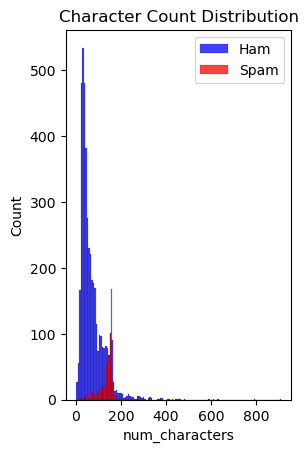

In [51]:
df['num_characters'] = df['text'].apply(len)
plt.subplot(1, 2, 2)
sns.histplot(df[df['target'] == 0]['num_characters'], color='blue', label='Ham')
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Spam')
plt.title('Character Count Distribution')
plt.legend()
plt.show()

In [ ]:
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])


In [36]:
df = df.drop_duplicates(keep='first')

In [37]:
stop_words = set(stopwords.words('english'))

def transform_text(text):
    tokens = nltk.word_tokenize(text.lower())
    return " ".join([ps.stem(w) for w in tokens if w.isalnum() and w not in stop_words])

df['transformed_text'] = df['text'].apply(transform_text)

df.head()

,target,text,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [38]:
##BOW
cv = CountVectorizer(max_features=3000)
X_cv = cv.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_cv, y, test_size=0.2, random_state=2)

mnb_cv = MultinomialNB()
mnb_cv.fit(X_train_cv, y_train_cv)
y_pred_cv = mnb_cv.predict(X_test_cv)

accuracy_cv = accuracy_score(y_test_cv, y_pred_cv)
precision_cv = precision_score(y_test_cv, y_pred_cv)


In [39]:
##TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(df['transformed_text']).toarray()

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(X_tfidf, y, test_size=0.2, random_state=2)

mnb_tf = MultinomialNB()
mnb_tf.fit(X_train_tf, y_train_tf)
y_pred_tf = mnb_tf.predict(X_test_tf)

accuracy_tf = accuracy_score(y_test_tf, y_pred_tf)
precision_tf = precision_score(y_test_tf, y_pred_tf)

In [ ]:
print(f"1. Bag of Words -> Accuracy: {accuracy_cv:.4f} | Precision: {precision_cv:.4f}")
print(f"2. TF-IDF       -> Accuracy: {accuracy_tf:.4f} | Precision: {precision_tf:.4f}")

1. Bag of Words -> Accuracy: 0.9720 | Precision: 0.8865
2. TF-IDF       -> Accuracy: 0.9710 | Precision: 1.0000


In [42]:
pickle.dump(best_vectorizer, open('../vectorizer.pkl','wb'))
pickle.dump(best_model, open('../model.pkl','wb'))
